In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import torch.optim as optim

In [100]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 5)
        nn.init.normal_(self.fc1.weight, mean=0.0, std=1.0)

        self.fc2 = nn.Linear(5, 5)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=1.0)

        self.fc3 = nn.Linear(5, 4)
        nn.init.normal_(self.fc3.weight, mean=0.0, std=1.0)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x) 
        return x

model = Net()

optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.1)

criterion = nn.CrossEntropyLoss()


In [101]:
data = pd.read_csv('data_lab3v01.csv', header=None, names=['x', 'y', 'class'])
data['class'] = data['class'] - 1 

X = data[['x', 'y']].values.astype(np.float32)
y = data['class'].values.astype(np.int64)

X = (X - X.mean(axis=0)) / X.std(axis=0)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, train_size=2/3, stratify=y_temp, random_state=42)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (300, 2), Val shape: (150, 2), Test shape: (50, 2)


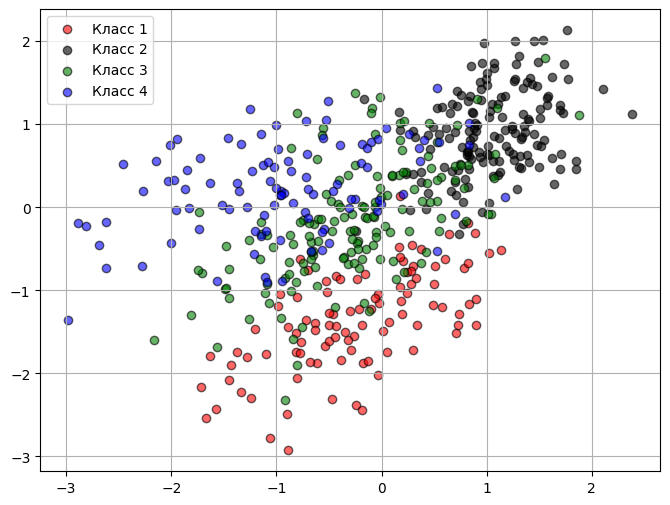

In [102]:
colors = ['red', 'black', 'green', 'blue']
plt.figure(figsize=(8, 6))
for cls in range(4): 
    plt.scatter(X[y == cls, 0], X[y == cls, 1], color=colors[cls],
                label=f'Класс {cls + 1}', alpha=0.6, edgecolor='k')
plt.legend()
plt.grid(True)
plt.show()


In [103]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [104]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)


In [105]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.1)

best_val_loss = float('inf')
patience = 20
patience_counter = 0

train_loader, val_loader, test_loader = train_loader, val_loader, test_loader

history = {
    'train_loss': [],
    'val_loss': [],
    'test_loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

for epoch in range(30000):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    with torch.no_grad():
        def eval_loss_acc(loader):
            loss_sum = 0
            correct = 0
            total = 0
            for X_batch, y_batch in loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss_sum += loss.item() * y_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
            return loss_sum / total, correct / total

        val_loss, val_acc = eval_loss_acc(val_loader)
        test_loss, test_acc = eval_loss_acc(test_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, test_loss={test_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"Остановка обучения после {epoch+1} эпох из-за отсутствия улучшения в течение {patience} эпох")
        break

train_error = [1 - acc for acc in history['train_acc']]
val_error = [1 - acc for acc in history['val_acc']]
test_error = [1 - acc for acc in history['test_acc']]


Epoch 1: train_loss=1.8260, val_loss=1.1040, test_loss=1.1038
Epoch 2: train_loss=0.9261, val_loss=0.8306, test_loss=0.8528
Epoch 3: train_loss=0.7959, val_loss=0.7657, test_loss=0.7913
Epoch 4: train_loss=0.7484, val_loss=0.7309, test_loss=0.7683
Epoch 5: train_loss=0.7112, val_loss=0.7057, test_loss=0.7563
Epoch 6: train_loss=0.6883, val_loss=0.6832, test_loss=0.7389
Epoch 7: train_loss=0.6692, val_loss=0.6811, test_loss=0.7264
Epoch 8: train_loss=0.6540, val_loss=0.6626, test_loss=0.7182
Epoch 9: train_loss=0.6439, val_loss=0.6579, test_loss=0.7104
Epoch 10: train_loss=0.6348, val_loss=0.6487, test_loss=0.7007
Epoch 11: train_loss=0.6286, val_loss=0.6424, test_loss=0.7028
Epoch 12: train_loss=0.6222, val_loss=0.6434, test_loss=0.6979
Epoch 13: train_loss=0.6185, val_loss=0.6365, test_loss=0.7033
Epoch 14: train_loss=0.6120, val_loss=0.6400, test_loss=0.7018
Epoch 15: train_loss=0.6082, val_loss=0.6241, test_loss=0.6896
Epoch 16: train_loss=0.6036, val_loss=0.6307, test_loss=0.6894
E

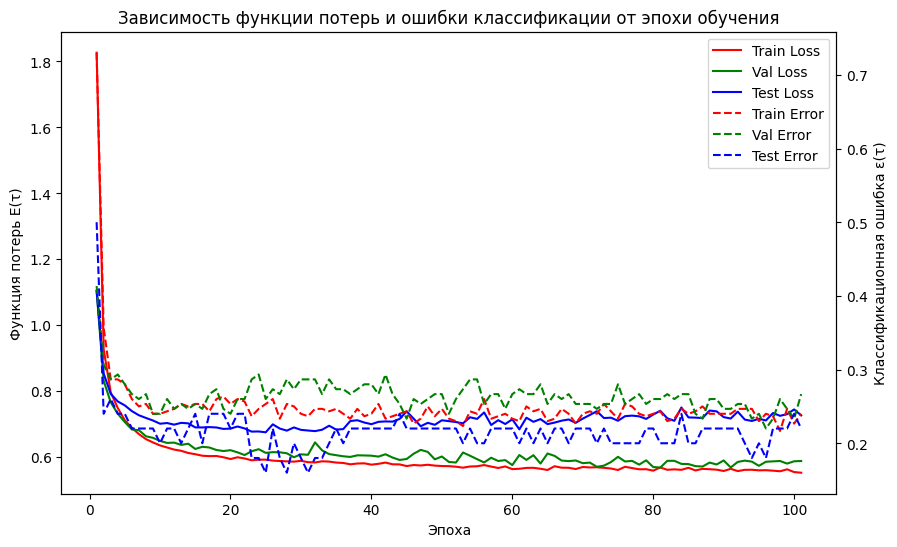

In [106]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Функция потерь E(τ)", color='black')
l1, = ax1.plot(epochs_range, history['train_loss'], 'r-', label='Train Loss')
l2, = ax1.plot(epochs_range, history['val_loss'],   'g-', label='Val Loss')
l3, = ax1.plot(epochs_range, history['test_loss'],  'b-', label='Test Loss')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.set_ylabel("Классификационная ошибка ε(τ)", color='black')
l4, = ax2.plot(epochs_range, train_error, 'r--', label='Train Error')
l5, = ax2.plot(epochs_range, val_error,   'g--', label='Val Error')
l6, = ax2.plot(epochs_range, test_error,  'b--', label='Test Error')
ax2.tick_params(axis='y', labelcolor='black')

lines = [l1, l2, l3, l4, l5, l6]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Зависимость функции потерь и ошибки классификации от эпохи обучения")
plt.show()


In [107]:
def evaluate_model(model, loader, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    all_targets = []
    all_preds = []
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_targets.extend(y_batch.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, 1 - accuracy, np.array(all_targets), np.array(all_preds) 

train_loss, train_error, y_train_true, y_train_pred = evaluate_model(model, train_loader)
val_loss, val_error, _, _ = evaluate_model(model, val_loader)
test_loss, test_error, y_test_true, y_test_pred = evaluate_model(model, test_loader)

print("\nПоказатели качества обученного классификатора:")
print(f"Обучающая выборка:       Loss = {train_loss:.3f}, Error = {train_error:.3f}")
print(f"Валидационная выборка:    Loss = {val_loss:.3f}, Error = {val_error:.3f}")
print(f"Тестовая выборка:         Loss = {test_loss:.3f}, Error = {test_error:.3f}")

cm_train = confusion_matrix(y_train_true, y_train_pred, labels=[0, 1, 2, 3])
cm_test = confusion_matrix(y_test_true, y_test_pred, labels=[0, 1, 2, 3])

print("\nМатрица ошибок — обучающая выборка:")
print(cm_train)
print("\nМатрица ошибок — тестовая выборка:")
print(cm_test)



Показатели качества обученного классификатора:
Обучающая выборка:       Loss = 0.547, Error = 0.243
Валидационная выборка:    Loss = 0.588, Error = 0.267
Тестовая выборка:         Loss = 0.726, Error = 0.220

Матрица ошибок — обучающая выборка:
[[55  0  5  0]
 [ 0 83  7  0]
 [10 12 49 19]
 [ 0  4 16 40]]

Матрица ошибок — тестовая выборка:
[[ 9  0  1  0]
 [ 1 14  0  0]
 [ 3  1 11  0]
 [ 1  1  3  5]]


In [108]:
def plot_decision_boundaries(model, X, y, mean_train, std_train, colors):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_norm = (grid - mean_train) / std_train

    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(grid_norm, dtype=torch.float32)
        outputs = model(inputs)
        Z = torch.argmax(outputs, axis=1).numpy()

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], colors=colors, alpha=0.3)
    for cls in range(4):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], color=colors[cls],
                    label=f'Класс {cls+1}', edgecolor='k')
    plt.legend()
    plt.show()


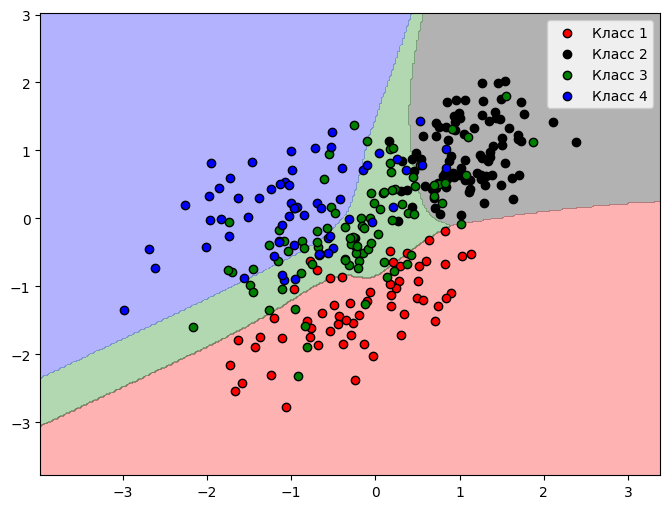

In [109]:
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

colors = ['red', 'black', 'green', 'blue']
plot_decision_boundaries(model, X_train, y_train, mean_train, std_train, colors)

In [115]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=24)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, train_size=2/3, stratify=y_temp, random_state=24)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)


In [116]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.1)

best_val_loss = float('inf')
patience = 20
patience_counter = 0

train_loader, val_loader, test_loader = train_loader, val_loader, test_loader

history = {
    'train_loss': [],
    'val_loss': [],
    'test_loss': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': []
}

for epoch in range(30000):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    
    model.eval()
    with torch.no_grad():
        def eval_loss_acc(loader):
            loss_sum = 0
            correct = 0
            total = 0
            for X_batch, y_batch in loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss_sum += loss.item() * y_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)
            return loss_sum / total, correct / total

        val_loss, val_acc = eval_loss_acc(val_loader)
        test_loss, test_acc = eval_loss_acc(test_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, test_loss={test_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"Остановка обучения после {epoch+1} эпох из-за отсутствия улучшения в течение {patience} эпох")
        break

train_error = [1 - acc for acc in history['train_acc']]
val_error = [1 - acc for acc in history['val_acc']]
test_error = [1 - acc for acc in history['test_acc']]


Epoch 1: train_loss=0.5740, val_loss=0.5248, test_loss=0.7448
Epoch 2: train_loss=0.5653, val_loss=0.5279, test_loss=0.7236
Epoch 3: train_loss=0.5660, val_loss=0.5256, test_loss=0.7521
Epoch 4: train_loss=0.5678, val_loss=0.5295, test_loss=0.7771
Epoch 5: train_loss=0.5662, val_loss=0.5297, test_loss=0.7795
Epoch 6: train_loss=0.5707, val_loss=0.5312, test_loss=0.7685
Epoch 7: train_loss=0.5589, val_loss=0.5357, test_loss=0.7245
Epoch 8: train_loss=0.5614, val_loss=0.5281, test_loss=0.7453
Epoch 9: train_loss=0.5655, val_loss=0.5292, test_loss=0.7521
Epoch 10: train_loss=0.5640, val_loss=0.5360, test_loss=0.7314
Epoch 11: train_loss=0.5616, val_loss=0.5269, test_loss=0.7524
Epoch 12: train_loss=0.5658, val_loss=0.5341, test_loss=0.7628
Epoch 13: train_loss=0.5674, val_loss=0.5288, test_loss=0.7196
Epoch 14: train_loss=0.5646, val_loss=0.5405, test_loss=0.7799
Epoch 15: train_loss=0.5652, val_loss=0.5404, test_loss=0.7737
Epoch 16: train_loss=0.5618, val_loss=0.5627, test_loss=0.8230
E

In [117]:
train_loss, train_error, y_train_true, y_train_pred = evaluate_model(model, train_loader)
val_loss, val_error, _, _ = evaluate_model(model, val_loader)
test_loss, test_error, y_test_true, y_test_pred = evaluate_model(model, test_loader)

print("\nПоказатели качества обученного классификатора:")
print(f"Обучающая выборка:       Loss = {train_loss:.3f}, Error = {train_error:.3f}")
print(f"Валидационная выборка:    Loss = {val_loss:.3f}, Error = {val_error:.3f}")
print(f"Тестовая выборка:         Loss = {test_loss:.3f}, Error = {test_error:.3f}")

cm_train = confusion_matrix(y_train_true, y_train_pred, labels=[0, 1, 2, 3])
cm_test = confusion_matrix(y_test_true, y_test_pred, labels=[0, 1, 2, 3])

print("\nМатрица ошибок — обучающая выборка:")
print(cm_train)
print("\nМатрица ошибок — тестовая выборка:")
print(cm_test)



Показатели качества обученного классификатора:
Обучающая выборка:       Loss = 0.545, Error = 0.237
Валидационная выборка:    Loss = 0.530, Error = 0.213
Тестовая выборка:         Loss = 0.744, Error = 0.280

Матрица ошибок — обучающая выборка:
[[54  0  6  0]
 [ 0 79 11  0]
 [ 9 14 59  8]
 [ 0  3 20 37]]

Матрица ошибок — тестовая выборка:
[[ 7  0  3  0]
 [ 0 14  0  1]
 [ 2  0 10  3]
 [ 0  0  5  5]]


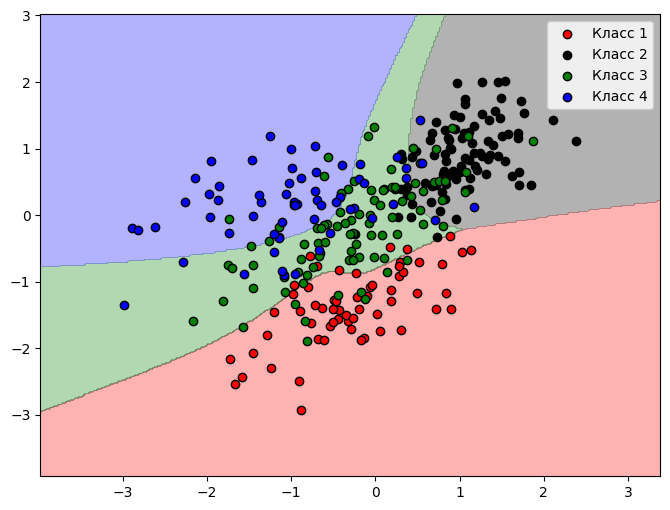

In [118]:
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

colors = ['red', 'black', 'green', 'blue']
plot_decision_boundaries(model, X_train, y_train, mean_train, std_train, colors)